# EDA dan Preprocessing Dataset Steel Plates Faults

Notebook ini digunakan untuk melakukan eksplorasi data (EDA), pemeriksaan kualitas data, preprocessing, dan feature engineering pada dataset Steel Plates Faults.

Tujuan preprocessing adalah menghasilkan dataset yang siap digunakan oleh:
1. ML Engineer 1 untuk supervised learning.
2. ML Engineer 2 untuk unsupervised learning.

## 1. Import Library

Pada tahap ini digunakan beberapa library Python untuk melakukan proses
pengolahan data, visualisasi, dan preprocessing.

Library yang digunakan antara lain:

- `pandas` untuk membaca dan mengolah dataset
- `numpy` untuk operasi numerik
- `matplotlib` untuk membuat visualisasi
- `seaborn` untuk visualisasi statistik
- `scikit-learn` untuk preprocessing dan pembagian dataset
- `joblib` untuk menyimpan objek preprocessing seperti scaler

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import joblib

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 2. Load Dataset

Dataset yang digunakan adalah **Steel Plates Faults**.

Dataset berisi karakteristik hasil pengukuran pada steel plate dan informasi
mengenai jenis fault atau kerusakan yang terdapat pada plate.

File dataset disimpan pada folder `data/` dengan nama `faults.csv`.

Karena notebook berada di dalam folder `notebooks/`, maka path dataset yang
digunakan adalah `../data/faults.csv`.

In [9]:
# Membaca dataset dari folder data
df = pd.read_csv("../data/faults.csv")

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)

Dataset berhasil dimuat.
Ukuran dataset: (1941, 34)


## 3. Melihat Data Awal

Sebelum melakukan preprocessing, dataset perlu diperiksa terlebih dahulu.

Pada tahap ini akan ditampilkan beberapa baris pertama dataset untuk melihat
struktur awal data dan nama kolom yang tersedia.

In [10]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


## 4. Informasi Dataset

Tahap ini digunakan untuk mengetahui struktur dataset secara keseluruhan,
termasuk jumlah data, nama kolom, tipe data, dan penggunaan memory.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empty_Index    

## 5. Ukuran Dataset

Ukuran dataset diperiksa kembali untuk mengetahui jumlah observasi dan
jumlah variabel yang tersedia.

In [13]:
rows, columns = df.shape

print("Jumlah baris :", rows)
print("Jumlah kolom :", columns)

Jumlah baris : 1941
Jumlah kolom : 34


## 6. Daftar Kolom

Selanjutnya dilakukan pemeriksaan terhadap seluruh nama kolom yang terdapat
dalam dataset.

In [14]:
print("Daftar kolom:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Daftar kolom:
1. X_Minimum
2. X_Maximum
3. Y_Minimum
4. Y_Maximum
5. Pixels_Areas
6. X_Perimeter
7. Y_Perimeter
8. Sum_of_Luminosity
9. Minimum_of_Luminosity
10. Maximum_of_Luminosity
11. Length_of_Conveyer
12. TypeOfSteel_A300
13. TypeOfSteel_A400
14. Steel_Plate_Thickness
15. Edges_Index
16. Empty_Index
17. Square_Index
18. Outside_X_Index
19. Edges_X_Index
20. Edges_Y_Index
21. Outside_Global_Index
22. LogOfAreas
23. Log_X_Index
24. Log_Y_Index
25. Orientation_Index
26. Luminosity_Index
27. SigmoidOfAreas
28. Pastry
29. Z_Scratch
30. K_Scatch
31. Stains
32. Dirtiness
33. Bumps
34. Other_Faults


## 7. Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat karakteristik numerik dari
dataset.

Informasi yang diperoleh antara lain:

- jumlah data
- rata-rata
- standar deviasi
- nilai minimum
- kuartil
- nilai maksimum

Informasi ini membantu mengidentifikasi perbedaan skala dan kemungkinan
adanya nilai ekstrem pada fitur.

In [15]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 8. Pemeriksaan Missing Value

Missing value adalah data yang tidak memiliki nilai.

Pemeriksaan ini dilakukan agar model Machine Learning tidak menerima data
yang kosong tanpa penanganan.

In [17]:
total_missing = df.isnull().sum().sum()

print("Total seluruh missing value:", total_missing)

Total seluruh missing value: 0


## 9. Pemeriksaan Data Duplikat

Data duplikat diperiksa untuk mengetahui apakah terdapat baris yang sama
secara keseluruhan.

Data duplikat yang tidak diperlukan dapat menyebabkan observasi tertentu
memiliki pengaruh lebih besar pada proses pembelajaran model.

In [18]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 0


## 10. Pemeriksaan Tipe Data

Tipe data setiap kolom diperiksa untuk memastikan bahwa fitur dapat digunakan
dalam proses Machine Learning.

Dataset Steel Plates Faults didominasi oleh data numerik.

In [19]:
print("Tipe data setiap kolom:")
print(df.dtypes)

Tipe data setiap kolom:
X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Minimum_of_Luminosity      int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
Pastry                     int64
Z_Scratch                  int64
K_Scatch           

## 11. Menentukan Feature dan Target

Dataset Steel Plates Faults memiliki fitur yang menggambarkan karakteristik
dari steel plate.

Dataset juga memiliki beberapa kolom target yang menunjukkan jenis fault.

Target yang digunakan terdiri dari:

- Pastry
- Z_Scratch
- K_Scatch
- Stains
- Dirtiness
- Bumps
- Other_Faults

Karena model supervised akan melakukan klasifikasi jenis kerusakan, ketujuh
kolom target tersebut akan diubah menjadi satu kolom target bernama
`Defect_Type`.

In [20]:
target_cols = [
    "Pastry",
    "Z_Scratch",
    "K_Scatch",
    "Stains",
    "Dirtiness",
    "Bumps",
    "Other_Faults"
]

feature_cols = [
    "X_Minimum",
    "X_Maximum",
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    "Length_of_Conveyer",
    "TypeOfSteel_A300",
    "TypeOfSteel_A400",
    "Steel_Plate_Thickness",
    "Edges_Index",
    "Empty_Index",
    "Square_Index",
    "Outside_X_Index",
    "Edges_X_Index",
    "Edges_Y_Index",
    "Outside_Global_Index",
    "LogOfAreas",
    "Log_X_Index",
    "Log_Y_Index",
    "Orientation_Index",
    "Luminosity_Index",
    "SigmoidOfAreas"
]

print("Jumlah feature:", len(feature_cols))
print("Jumlah target:", len(target_cols))

Jumlah feature: 27
Jumlah target: 7


## 12. Pemeriksaan Label Target

Sebelum mengubah tujuh kolom target menjadi satu label, dilakukan pemeriksaan
untuk mengetahui jumlah label aktif pada setiap baris.

Idealnya setiap observasi memiliki satu jenis fault aktif.

In [21]:
target_sum = df[target_cols].sum(axis=1)

print("Distribusi jumlah label aktif per baris:")
print(target_sum.value_counts().sort_index())

Distribusi jumlah label aktif per baris:
1    1941
Name: count, dtype: int64


## 13. Membuat Defect_Type

Tujuh kolom target akan direpresentasikan menjadi satu kolom bernama
`Defect_Type`.

Kolom ini akan berisi nama jenis defect untuk setiap observasi.


In [22]:
df["Defect_Type"] = df[target_cols].idxmax(axis=1)

print("Contoh hasil konversi target:")
print(df[["Defect_Type"]].head(10))

Contoh hasil konversi target:
  Defect_Type
0      Pastry
1      Pastry
2      Pastry
3      Pastry
4      Pastry
5      Pastry
6      Pastry
7      Pastry
8      Pastry
9      Pastry


## 14. Distribusi Jenis Defect

Distribusi kelas diperiksa untuk mengetahui jumlah data pada setiap jenis
kerusakan.

Informasi ini penting untuk mengetahui apakah terdapat ketidakseimbangan
jumlah data antar kelas.

In [23]:
defect_counts = df["Defect_Type"].value_counts()

print("Jumlah data untuk setiap jenis defect:")
print(defect_counts)

Jumlah data untuk setiap jenis defect:
Defect_Type
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64


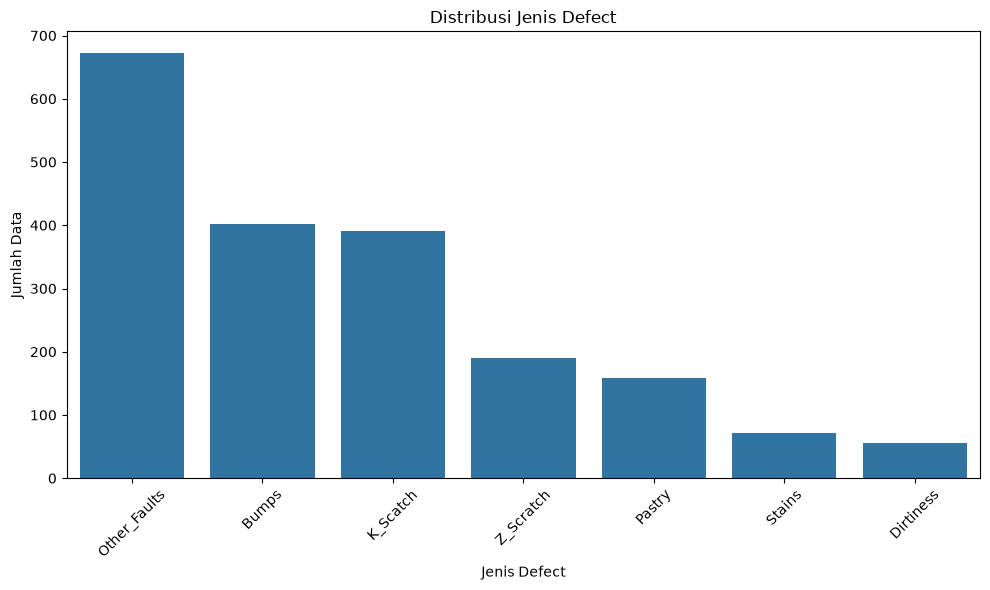

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Defect_Type",
    order=defect_counts.index
)

plt.title("Distribusi Jenis Defect")
plt.xlabel("Jenis Defect")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 15. Analisis Korelasi Feature

Correlation heatmap digunakan untuk melihat hubungan antar feature numerik.

Nilai korelasi mendekati:

- `1` menunjukkan hubungan positif yang kuat
- `-1` menunjukkan hubungan negatif yang kuat
- `0` menunjukkan hubungan linear yang lemah

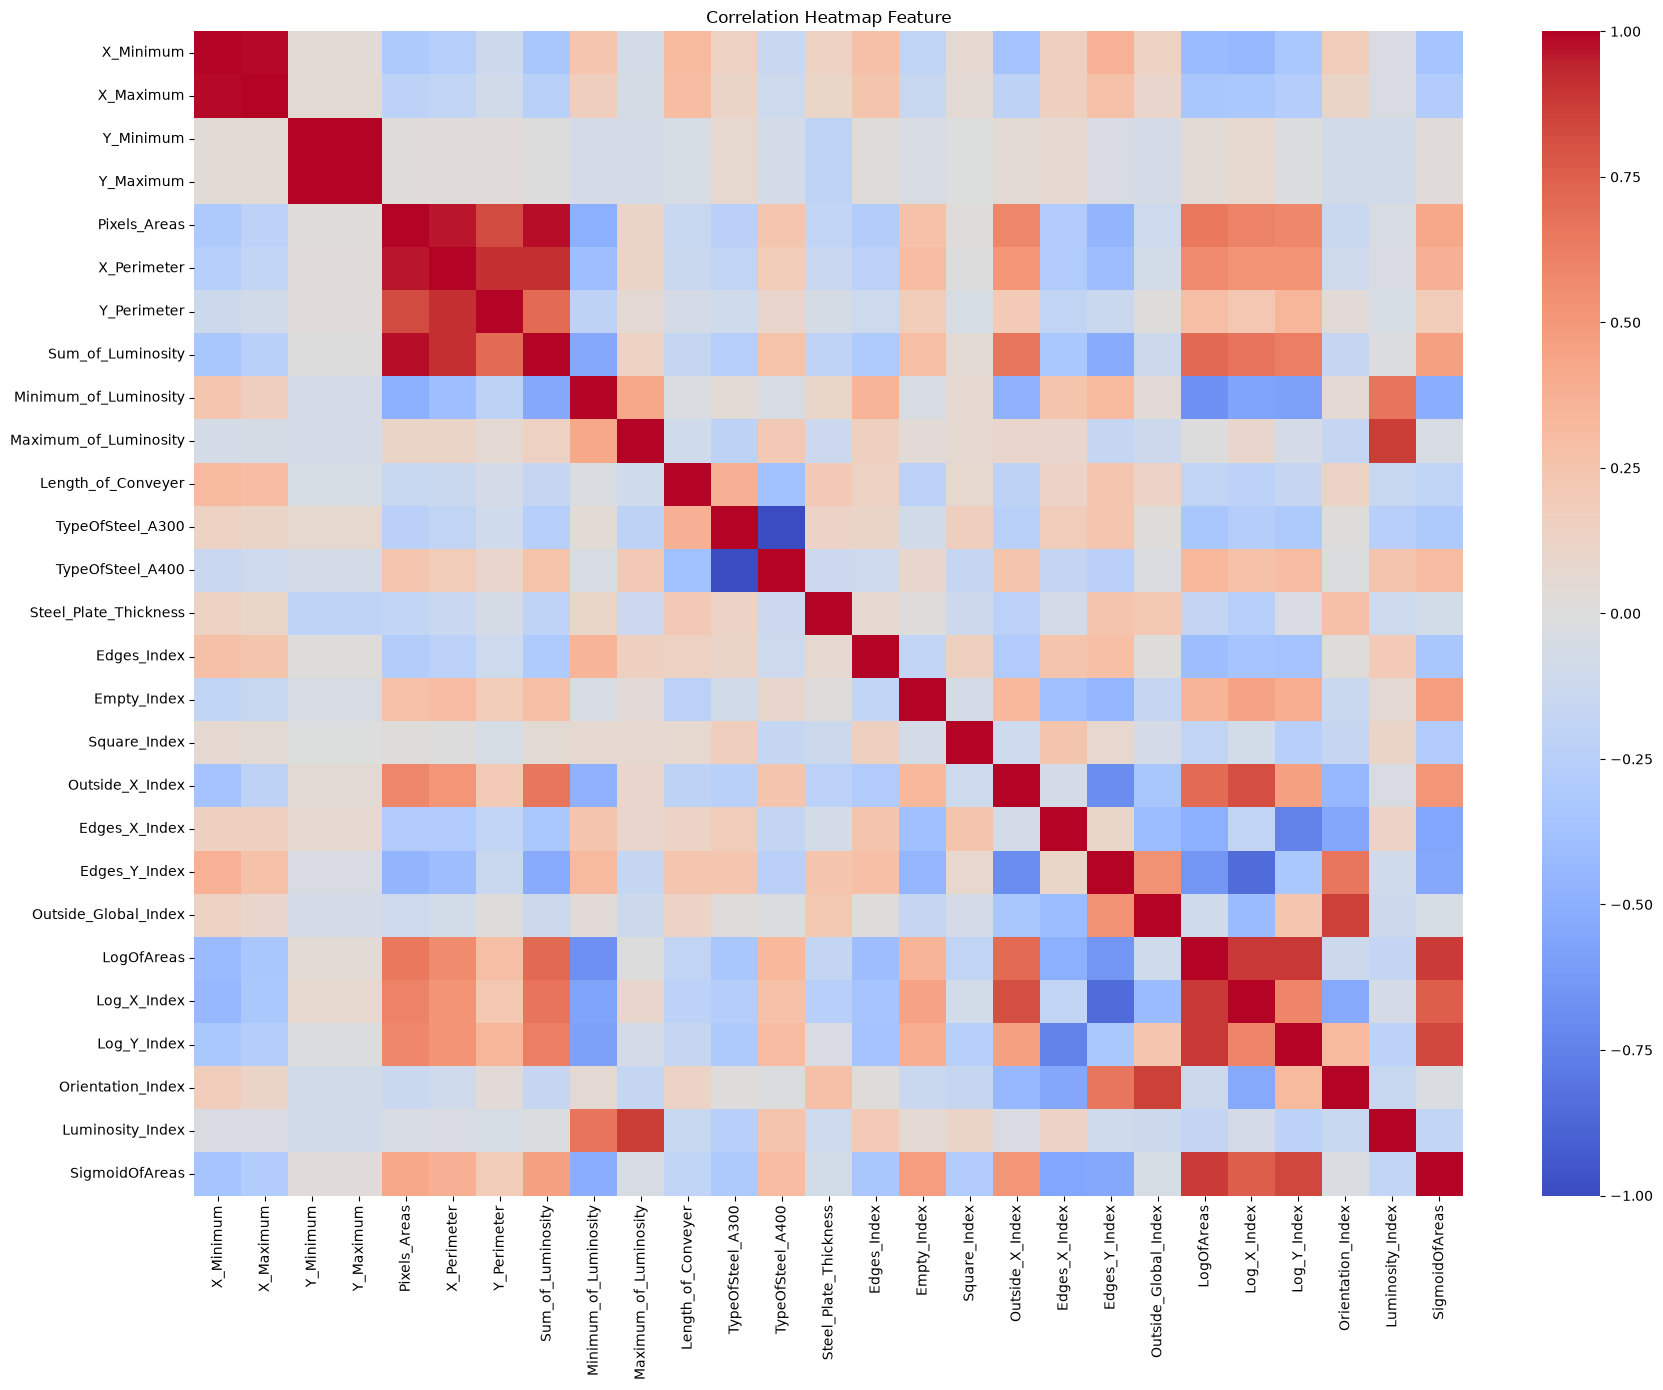

In [25]:
plt.figure(figsize=(18, 14))

correlation = df[feature_cols].corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap Feature")
plt.tight_layout()
plt.show()

## 16. Distribusi Feature

Histogram digunakan untuk melihat distribusi nilai pada beberapa feature
numerik.

Visualisasi ini membantu mengetahui bentuk distribusi data dan kemungkinan
adanya nilai yang sangat ekstrem.

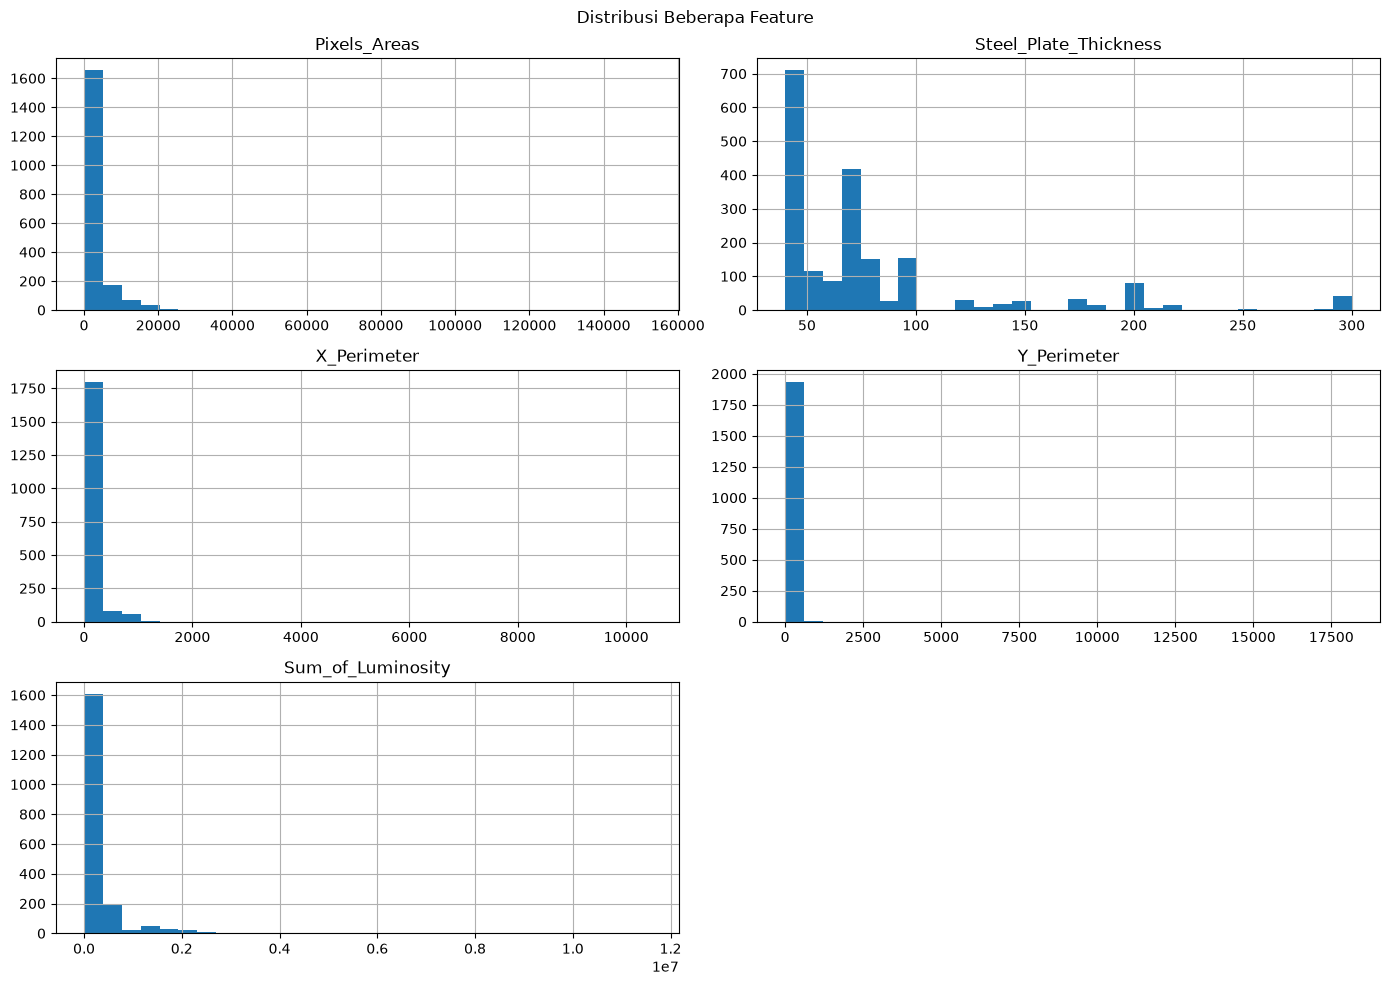

In [26]:
selected_features = [
    "Pixels_Areas",
    "Steel_Plate_Thickness",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity"
]

df[selected_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribusi Beberapa Feature")
plt.tight_layout()
plt.show()

## 17. Pemeriksaan Outlier

Boxplot digunakan untuk melihat persebaran data dan kemungkinan adanya
outlier pada beberapa feature.

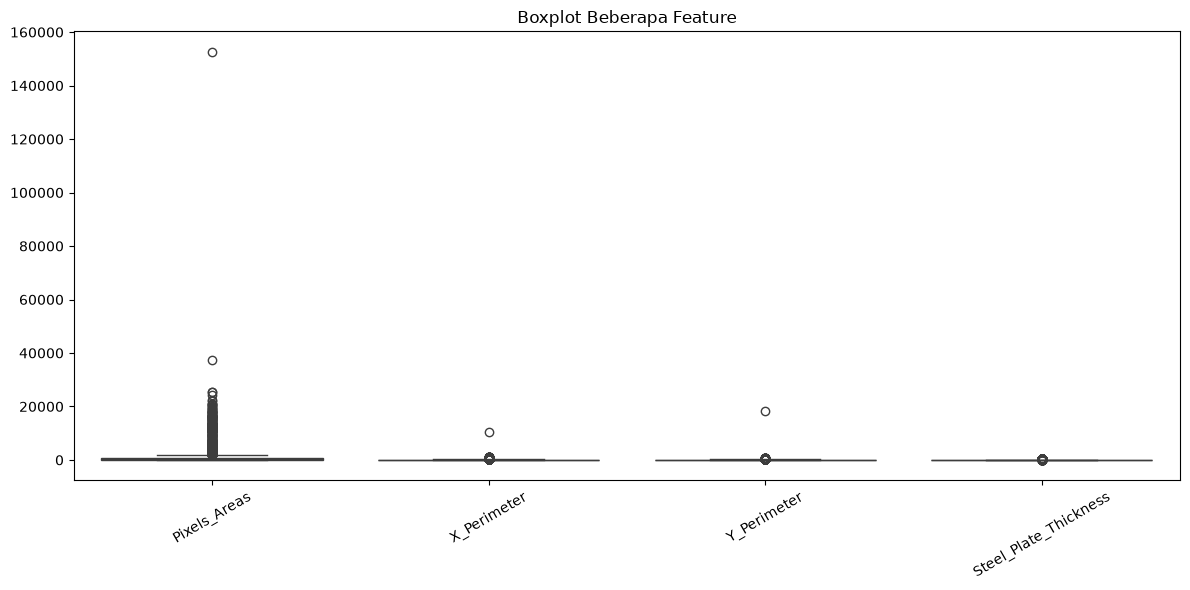

In [27]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        [
            "Pixels_Areas",
            "X_Perimeter",
            "Y_Perimeter",
            "Steel_Plate_Thickness"
        ]
    ]
)

plt.title("Boxplot Beberapa Feature")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 18. Feature Engineering

Feature engineering dilakukan dengan membuat feature baru berdasarkan
feature yang telah tersedia.

Dua feature tambahan yang dibuat adalah:

- `Defect_Width` = `X_Maximum - X_Minimum`
- `Defect_Height` = `Y_Maximum - Y_Minimum`

Feature tersebut merepresentasikan ukuran defect berdasarkan batas koordinat.

In [28]:
df["Defect_Width"] = df["X_Maximum"] - df["X_Minimum"]

df["Defect_Height"] = df["Y_Maximum"] - df["Y_Minimum"]

print("Feature engineering berhasil dilakukan.")

print("\nContoh hasil:")
print(
    df[
        [
            "X_Minimum",
            "X_Maximum",
            "Defect_Width",
            "Y_Minimum",
            "Y_Maximum",
            "Defect_Height"
        ]
    ].head()
)

Feature engineering berhasil dilakukan.

Contoh hasil:
   X_Minimum  X_Maximum  Defect_Width  Y_Minimum  Y_Maximum  Defect_Height
0         42         50             8     270900     270944             44
1        645        651             6    2538079    2538108             29
2        829        835             6    1553913    1553931             18
3        853        860             7     369370     369415             45
4       1289       1306            17     498078     498335            257


## 19. Update Daftar Feature

Setelah feature engineering, dua feature baru ditambahkan ke daftar feature
yang akan digunakan dalam proses Machine Learning.

In [29]:
feature_cols_final = feature_cols + [
    "Defect_Width",
    "Defect_Height"
]

print("Jumlah feature sebelum feature engineering:", len(feature_cols))
print("Jumlah feature setelah feature engineering:", len(feature_cols_final))

Jumlah feature sebelum feature engineering: 27
Jumlah feature setelah feature engineering: 29


## 20. Memisahkan Feature dan Target

Data dipisahkan menjadi:

- `X` sebagai feature/input
- `y` sebagai target/output

`X` akan digunakan sebagai input Machine Learning, sedangkan `y` berisi
jenis defect yang ingin diprediksi.

In [30]:
X = df[feature_cols_final].copy()
y = df["Defect_Type"].copy()

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (1941, 29)
Ukuran y: (1941,)


## 21. Train-Test Split

Dataset dibagi menjadi:

- 80% data training
- 20% data testing

`random_state=42` digunakan agar hasil pembagian dapat direproduksi.

`stratify=y` digunakan untuk menjaga proporsi kelas defect pada data
training dan testing.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)
print("Target training:", y_train.shape)
print("Target testing :", y_test.shape)

Data training : (1552, 29)
Data testing  : (389, 29)
Target training: (1552,)
Target testing : (389,)


## 22. Feature Scaling

Feature pada dataset memiliki skala nilai yang berbeda.

StandardScaler digunakan untuk melakukan standardisasi feature.

Scaler hanya di-fit menggunakan data training untuk mencegah data leakage.

Data testing kemudian ditransformasi menggunakan scaler yang telah dipelajari
dari data training.

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil dilakukan.")
print("Ukuran X_train_scaled:", X_train_scaled.shape)
print("Ukuran X_test_scaled :", X_test_scaled.shape)

Scaling berhasil dilakukan.
Ukuran X_train_scaled: (1552, 29)
Ukuran X_test_scaled : (389, 29)


## 23. Pemeriksaan Hasil Scaling

Setelah scaling dilakukan, rata-rata dan standar deviasi beberapa feature
training diperiksa untuk memastikan proses standardisasi berjalan dengan baik.

In [33]:
print("Rata-rata 5 feature pertama:")
print(np.mean(X_train_scaled, axis=0)[:5])

print("\nStandar deviasi 5 feature pertama:")
print(np.std(X_train_scaled, axis=0)[:5])

Rata-rata 5 feature pertama:
[-6.75290293e-17  6.86735892e-18  2.17466366e-17  5.37943115e-17
  0.00000000e+00]

Standar deviasi 5 feature pertama:
[1. 1. 1. 1. 1.]


## 24. Menyimpan Scaler

Scaler disimpan menggunakan `joblib` agar dapat digunakan kembali ketika
model melakukan prediksi terhadap data baru.

Scaler yang sama harus digunakan pada data input baru agar preprocessing
konsisten dengan proses training.


In [34]:
import os

os.makedirs("../models", exist_ok=True)

scaler_path = "../models/standard_scaler.pkl"

joblib.dump(scaler, scaler_path)

print("Scaler berhasil disimpan.")
print("Lokasi:", scaler_path)

Scaler berhasil disimpan.
Lokasi: ../models/standard_scaler.pkl


## 25. Membuat Cleaned Dataset

Cleaned dataset dibuat dengan mengambil seluruh feature hasil feature
engineering dan satu target `Defect_Type`.

Dataset ini akan digunakan oleh Machine Learning Engineer.

In [35]:
clean_df = df[
    feature_cols_final + ["Defect_Type"]
].copy()

print("Ukuran cleaned dataset:", clean_df.shape)

clean_df.head()

Ukuran cleaned dataset: (1941, 30)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Defect_Width,Defect_Height,Defect_Type
0,42,50,270900,270944,267,17,44,24220,76,108,...,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,8,44,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,6,29,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,6,18,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,7,45,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,17,257,Pastry


## 26. Export Cleaned Dataset

Cleaned dataset disimpan dalam format CSV agar dapat digunakan oleh anggota
Machine Learning Engineer untuk proses training model.

In [36]:
cleaned_path = "../data/steel_plates_clean.csv"

clean_df.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset berhasil disimpan.")
print("Lokasi:", cleaned_path)

Cleaned dataset berhasil disimpan.
Lokasi: ../data/steel_plates_clean.csv


## 27. Export Training dan Testing Dataset

Data training dan testing disimpan secara terpisah agar Machine Learning
Engineer dapat langsung menggunakannya pada tahap pembangunan model.

In [37]:
train_df = X_train.copy()
train_df["Defect_Type"] = y_train.values

test_df = X_test.copy()
test_df["Defect_Type"] = y_test.values

train_df.to_csv(
    "../data/train.csv",
    index=False
)

test_df.to_csv(
    "../data/test.csv",
    index=False
)

print("Training dataset berhasil disimpan.")
print("Testing dataset berhasil disimpan.")

Training dataset berhasil disimpan.
Testing dataset berhasil disimpan.


## 28. Final Data Validation

Tahap terakhir dilakukan untuk memastikan dataset hasil preprocessing dapat
digunakan oleh Machine Learning Engineer.

Pemeriksaan meliputi:

- ukuran dataset
- jumlah feature
- jumlah kelas
- missing value
- duplicate
- daftar kelas target

In [38]:
print("=" * 50)
print("FINAL DATA VALIDATION")
print("=" * 50)

print("\n1. Ukuran dataset:")
print("   Cleaned :", clean_df.shape)
print("   Train   :", train_df.shape)
print("   Test    :", test_df.shape)

print("\n2. Jumlah feature:")
print("   ", len(feature_cols_final))

print("\n3. Jumlah kelas:")
print("   ", y.nunique())

print("\n4. Daftar kelas:")
print("   ", sorted(y.unique()))

print("\n5. Missing value:")
print("   ", clean_df.isnull().sum().sum())

print("\n6. Duplicate:")
print("   ", clean_df.duplicated().sum())

print("\n" + "=" * 50)
print("DATA ENGINEERING SELESAI")
print("=" * 50)

FINAL DATA VALIDATION

1. Ukuran dataset:
   Cleaned : (1941, 30)
   Train   : (1552, 30)
   Test    : (389, 30)

2. Jumlah feature:
    29

3. Jumlah kelas:
    7

4. Daftar kelas:
    ['Bumps', 'Dirtiness', 'K_Scatch', 'Other_Faults', 'Pastry', 'Stains', 'Z_Scratch']

5. Missing value:
    0

6. Duplicate:
    0

DATA ENGINEERING SELESAI
